# Longitudinal Structure & Honest Evaluation

**Project:** crohns-microbiome-ml &nbsp;|&nbsp; **Notebook 04** &nbsp;|&nbsp; Roadmap Week 5

HMP2 is a **longitudinal** cohort: each participant was sampled at several visits over time. Every
analysis so far has quietly treated the 178 samples as independent — they are not. This notebook
takes the time structure seriously, and the payoff is the single most important result in the
project: **what the model's accuracy looks like once we stop letting it cheat on patient identity.**

Three parts:
1. Map the repeated-measures structure (who has how many visits).
2. Follow microbiome **diversity over time** and relate it to clinical disease activity.
3. Re-evaluate the classifier with **patient-level splits** and decide how the final model should
   be trained.

In [1]:
import sys, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, spearmanr
import microbiome as mb

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, GroupKFold, cross_val_predict
from sklearn.metrics import roc_auc_score

otu_meta, counts, taxa = mb.load_otu_meta()

# Shannon diversity per sample, from raw relative abundances
rel = counts.div(counts.sum(axis=1), axis=0)
otu_meta = otu_meta.copy()
otu_meta['shannon'] = -(rel * np.log(rel.where(rel > 0))).sum(axis=1)

# Clinical activity lives on other metadata rows for the same visit — join by (participant, week)
meta = pd.read_csv('../data/hmp2_metadata_2018-08-20.csv', low_memory=False)
visit = (meta.groupby(['Participant ID', 'week_num'])
             .agg({'fecalcal': 'max', 'hbi': 'max'}).reset_index())
key = otu_meta[['Participant ID', 'week_num']].copy()
key['week_num'] = key['week_num'].astype(float)
visit['week_num'] = visit['week_num'].astype(float)
m = key.merge(visit, on=['Participant ID', 'week_num'], how='left'); m.index = otu_meta.index
otu_meta['fecalcal'] = m['fecalcal']   # fecal calprotectin (µg/g), inflammation marker
otu_meta['hbi'] = m['hbi']             # Harvey-Bradshaw Index, CD activity

print(f"{otu_meta['Participant ID'].nunique()} participants across {len(otu_meta)} samples")
print(f"HBI available on {otu_meta['hbi'].notna().sum()} samples, "
      f"fecal calprotectin on {otu_meta['fecalcal'].notna().sum()}")

81 participants across 178 samples
HBI available on 64 samples, fecal calprotectin on 85


## 1. Repeated-measures structure

If the 178 samples were independent, the histogram below would be all 1s. It isn't — a sizeable
share of participants contribute several visits, which is exactly what makes naive cross-validation
dishonest later.

13 participants have >=3 visits; 8 have >=4.


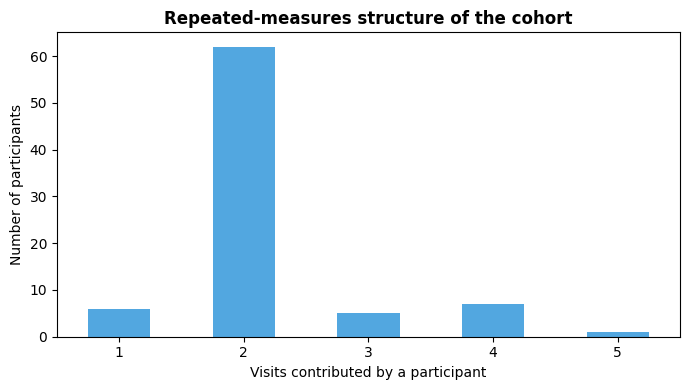

In [2]:
vc = otu_meta['Participant ID'].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
vc.value_counts().sort_index().plot(kind='bar', ax=ax, color='#3498db', alpha=0.85)
ax.set_xlabel('Visits contributed by a participant')
ax.set_ylabel('Number of participants')
ax.set_title('Repeated-measures structure of the cohort', fontweight='bold')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.savefig('../figures/visits_per_participant.png', dpi=150)
print(f"{(vc >= 3).sum()} participants have >=3 visits; {(vc >= 4).sum()} have >=4."); plt.show()

## 2. Diversity over time and disease activity

We plot Shannon diversity across visits for the participants with the longest follow-up (>=4
visits), coloured by diagnosis. A flat line means a stable community; swings mean the microbiome is
in flux — which, in IBD, often tracks disease activity.

Saved figures/shannon_trajectories.png


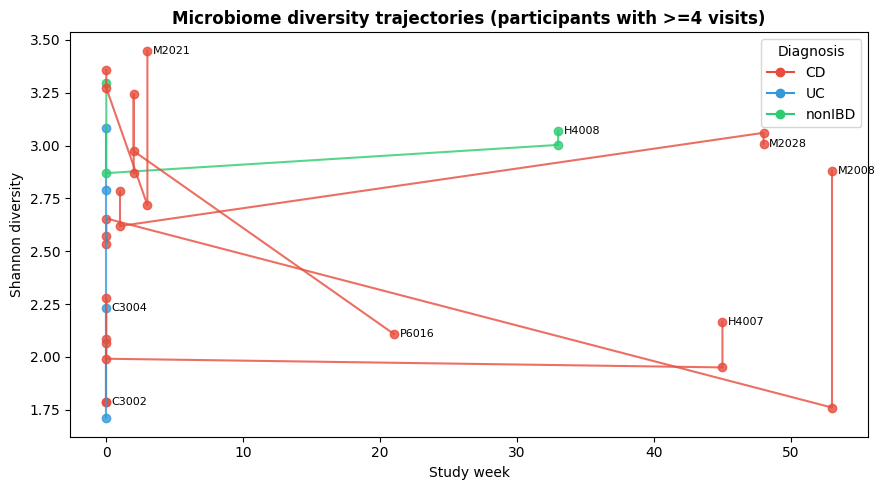

In [3]:
long_pts = vc[vc >= 4].index
fig, ax = plt.subplots(figsize=(9, 5))
colors = {'CD': '#e74c3c', 'UC': '#3498db', 'nonIBD': '#2ecc71'}
for pid in long_pts:
    d = otu_meta[otu_meta['Participant ID'] == pid].sort_values('week_num')
    dx = d['diagnosis'].iloc[0]
    ax.plot(d['week_num'], d['shannon'], marker='o', color=colors[dx], alpha=0.8)
    ax.annotate(pid, (d['week_num'].iloc[-1], d['shannon'].iloc[-1]), fontsize=8,
                xytext=(4, 0), textcoords='offset points', va='center')
handles = [plt.Line2D([0], [0], color=c, marker='o', label=dx) for dx, c in colors.items()]
ax.legend(handles=handles, title='Diagnosis')
ax.set_xlabel('Study week'); ax.set_ylabel('Shannon diversity')
ax.set_title('Microbiome diversity trajectories (participants with >=4 visits)', fontweight='bold')
plt.tight_layout(); plt.savefig('../figures/shannon_trajectories.png', dpi=150)
print('Saved figures/shannon_trajectories.png'); plt.show()

**Does diversity track disease activity?** We use two clinical readouts recorded at the same
visits: the **Harvey-Bradshaw Index** (HBI; HBI < 5 = clinical remission, >= 5 = active disease)
for Crohn's patients, and **fecal calprotectin**, a direct biochemical marker of gut inflammation.

Remission Shannon 2.56 (n=31) vs Active 2.25 (n=33)
Saved figures/diversity_vs_activity.png


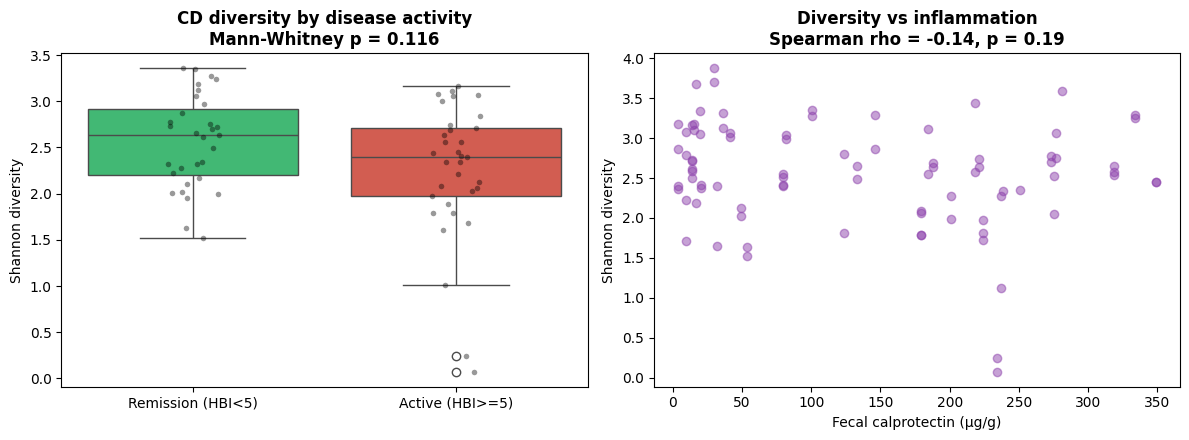

In [4]:
cd = otu_meta[otu_meta['diagnosis'] == 'CD'].dropna(subset=['hbi']).copy()
cd['activity'] = np.where(cd['hbi'] < 5, 'Remission (HBI<5)', 'Active (HBI>=5)')
rem = cd[cd['activity'].str.startswith('Rem')]['shannon']
act = cd[cd['activity'].str.startswith('Act')]['shannon']
u, p_hbi = mannwhitneyu(rem, act)

fc = otu_meta.dropna(subset=['fecalcal'])
rho, p_fc = spearmanr(fc['fecalcal'], fc['shannon'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
order = ['Remission (HBI<5)', 'Active (HBI>=5)']
sns.boxplot(data=cd, x='activity', y='shannon', order=order,
            palette=['#2ecc71', '#e74c3c'], ax=axes[0])
sns.stripplot(data=cd, x='activity', y='shannon', order=order, color='black',
              alpha=0.4, size=4, ax=axes[0])
axes[0].set_title(f'CD diversity by disease activity\nMann-Whitney p = {p_hbi:.3f}', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('Shannon diversity')

axes[1].scatter(fc['fecalcal'], fc['shannon'], alpha=0.5, color='#8e44ad')
axes[1].set_xlabel('Fecal calprotectin (µg/g)'); axes[1].set_ylabel('Shannon diversity')
axes[1].set_title(f'Diversity vs inflammation\nSpearman rho = {rho:.2f}, p = {p_fc:.2f}', fontweight='bold')
plt.tight_layout(); plt.savefig('../figures/diversity_vs_activity.png', dpi=150)
print(f"Remission Shannon {rem.mean():.2f} (n={len(rem)}) vs Active {act.mean():.2f} (n={len(act)})")
print('Saved figures/diversity_vs_activity.png'); plt.show()

**What the activity analysis shows.** Active Crohn's samples carry lower mean Shannon diversity
than remission samples, and inflammation (calprotectin) correlates *negatively* with diversity —
both in the biologically-expected direction (a disturbed, inflamed gut hosts a less diverse
community). But neither reaches significance: the within-CD activity contrast is only n≈31 vs 33,
and calprotectin is noisy. The honest read is **a consistent trend, underpowered by cohort size** —
the strong, significant diversity signal is the cross-sectional CD-vs-healthy difference
(established in notebook 01 and revisited below), not the within-patient activity contrast.

## 3. The honest evaluation: patient-level splits

Now the consequence. A plain 5-fold split shuffles **samples**, so two visits from the same
participant can land in different folds — the model can memorise that participant and be tested on
them. `GroupKFold` keeps **all of a participant's samples in the same fold**, so every test sample
comes from a person the model has never seen. That is the question that actually matters
clinically: *can it diagnose a new patient?*

Samples: 132 from 59 participants
Naive 5-fold        AUC: 0.825 ± 0.120
GroupKFold (patient) AUC: 0.681 ± 0.171
Saved figures/cv_leakage.png


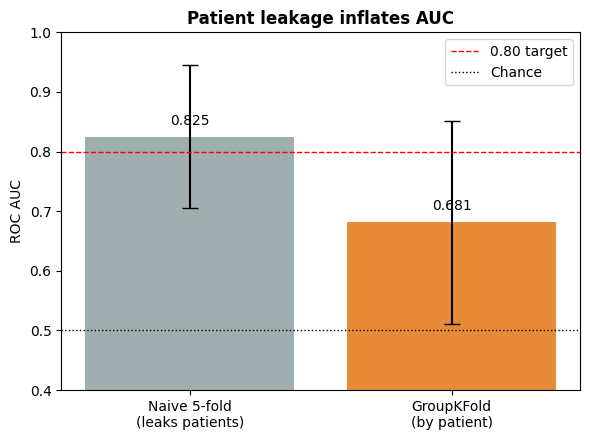

In [5]:
otu_final = mb.preprocess(counts)
X, y = mb.cd_vs_nonibd(otu_final, otu_meta)
groups = otu_meta.loc[X.index, 'Participant ID']
rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1, class_weight='balanced')

naive = cross_val_score(rf, X, y, cv=5, scoring='roc_auc')
gkf = GroupKFold(n_splits=5)
grouped = cross_val_score(rf, X, y, cv=gkf.split(X, y, groups), scoring='roc_auc')

print(f"Samples: {len(X)} from {groups.nunique()} participants")
print(f"Naive 5-fold        AUC: {naive.mean():.3f} ± {naive.std():.3f}")
print(f"GroupKFold (patient) AUC: {grouped.mean():.3f} ± {grouped.std():.3f}")

fig, ax = plt.subplots(figsize=(6, 4.5))
means = [naive.mean(), grouped.mean()]; errs = [naive.std(), grouped.std()]
bars = ax.bar(['Naive 5-fold\n(leaks patients)', 'GroupKFold\n(by patient)'], means,
              yerr=errs, capsize=6, color=['#95a5a6', '#e67e22'], alpha=0.9)
ax.axhline(0.80, color='red', linestyle='--', lw=1, label='0.80 target')
ax.axhline(0.50, color='black', linestyle=':', lw=1, label='Chance')
ax.set_ylabel('ROC AUC'); ax.set_ylim(0.4, 1.0)
ax.set_title('Patient leakage inflates AUC', fontweight='bold')
for b, mn in zip(bars, means): ax.text(b.get_x()+b.get_width()/2, mn+0.02, f'{mn:.3f}', ha='center')
ax.legend()
plt.tight_layout(); plt.savefig('../figures/cv_leakage.png', dpi=150)
print('Saved figures/cv_leakage.png'); plt.show()

### Modeling decision

The gap is the result: **AUC falls from ~0.83 to ~0.68 once the model can no longer see a test
patient during training.** The ~0.83 was real but optimistic — it partly measured the model
recognising individuals. The ~0.68 is the honest estimate of diagnosing an *unseen* patient from a
single stool sample, and it is the number this project should report as its headline.

Decisions for the final model:
- **Evaluate with `GroupKFold` by participant**, always. Sample-level CV is off the table.
- **Keep all timepoints** rather than averaging to one-row-per-patient: it preserves sample size
  and lets the model see within-patient variation, as long as the grouped split prevents leakage.
- **Frame the result honestly.** A single 16S snapshot separates Crohn's from healthy *well above
  chance* (~0.68 AUC) but is not a stand-alone diagnostic — consistent with IBD being driven by
  host genetics and immunology that the microbiome reflects only partly. The most reliable
  microbiome signal here is the **community-wide diversity reduction**, not a clean per-sample
  classifier.

Notebook 05 takes the Random Forest forward to ask *which* taxa carry what signal there is.